In [ ]:
# Importando as bibliotecas utilizadas

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, precision_recall_curve, average_precision_score, confusion_matrix, precision_score, recall_score

In [ ]:
# Carregando a base de dados

df = pd.read_csv('/content/drive/MyDrive/CDD/24.1 - Inteligência Artificial e Machine Learning/Inteligência Artificial: Model LifeCycle/AT_Customer_Churn.csv')

df

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3145,21,0,19,2,6697,147,92,44,2,2,1,25,721.980,0
3146,17,0,17,1,9237,177,80,42,5,1,1,55,261.210,0
3147,13,0,18,4,3157,51,38,21,3,1,1,30,280.320,0
3148,7,0,11,2,4695,46,222,12,3,1,1,30,1077.640,0


In [ ]:
df.describe()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
count,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000
mean,7.627937,0.076508,32.541905,0.942857,4472.459683,69.460635,73.174921,23.509841,2.826032,1.077778,1.248254,30.998413,470.972916,0.157143
std,7.263886,0.265851,8.573482,1.521072,4197.908687,57.413308,112.237560,17.217337,0.892555,0.267864,0.432069,8.831095,517.015433,0.363993
min,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,15.000000,0.000000,0.000000
25%,1.000000,0.000000,30.000000,0.000000,1391.250000,27.000000,6.000000,10.000000,2.000000,1.000000,1.000000,25.000000,113.801250,0.000000
50%,6.000000,0.000000,35.000000,0.000000,2990.000000,54.000000,21.000000,21.000000,3.000000,1.000000,1.000000,30.000000,228.480000,0.000000
75%,12.000000,0.000000,38.000000,1.000000,6478.250000,95.000000,87.000000,34.000000,3.000000,1.000000,1.000000,30.000000,788.388750,0.000000
max,36.000000,1.000000,47.000000,10.000000,17090.000000,255.000000,522.000000,97.000000,5.000000,2.000000,2.000000,55.000000,2165.280000,1.000000


In [ ]:
# Eliminando as variáveis irrelevantes
df = df.drop(['Status', 'Customer Value'], axis=1)

df

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Age,Churn
0,8,0,38,0,4370,71,5,17,3,1,30,0
1,0,0,39,0,318,5,7,4,2,1,25,0
2,10,0,37,0,2453,60,359,24,3,1,30,0
3,10,0,38,0,4198,66,1,35,1,1,15,0
4,3,0,38,0,2393,58,2,33,1,1,15,0
...,...,...,...,...,...,...,...,...,...,...,...,...
3145,21,0,19,2,6697,147,92,44,2,2,25,0
3146,17,0,17,1,9237,177,80,42,5,1,55,0
3147,13,0,18,4,3157,51,38,21,3,1,30,0
3148,7,0,11,2,4695,46,222,12,3,1,30,0


In [ ]:
# Convertendo segundos para horas
df['Hours of Use'] = df['Seconds of Use'] / 3600

# Removendo a variável antiga
df.drop('Seconds of Use', axis=1, inplace=True)

df

,Call Failure,Complains,Subscription Length,Charge Amount,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Age,Churn,Hours of Use
0,8,0,38,0,71,5,17,3,1,30,0,1.213889
1,0,0,39,0,5,7,4,2,1,25,0,0.088333
2,10,0,37,0,60,359,24,3,1,30,0,0.681389
3,10,0,38,0,66,1,35,1,1,15,0,1.166111
4,3,0,38,0,58,2,33,1,1,15,0,0.664722
...,...,...,...,...,...,...,...,...,...,...,...,...
3145,21,0,19,2,147,92,44,2,2,25,0,1.860278
3146,17,0,17,1,177,80,42,5,1,55,0,2.565833
3147,13,0,18,4,51,38,21,3,1,30,0,0.876944
3148,7,0,11,2,46,222,12,3,1,30,0,1.304167


In [ ]:
# Separando as features e o target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Separando os dados em conjunto de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Exibindo as dimensões dos conjuntos de treino e teste
print("Dimensões dos conjuntos de treino:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("\nDimensões dos conjuntos de teste:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Dimensões dos conjuntos de treino:
X_train: (2205, 11)
y_train: (2205,)

Dimensões dos conjuntos de teste:
X_test: (945, 11)
y_test: (945,)


# KNN

In [ ]:
# Lista de valores de K
k_values = list(range(1, 21))

# Dicionário para armazenar cada resultado
k_scores = {}

# Testando os valores de K
for k in k_values:
  knn = KNeighborsClassifier(n_neighbors=k)
  scores = cross_val_score(knn, X_train, y_train, cv=10, scoring='accuracy')
  k_scores[k] = scores.mean()

# Encontrando o melhor valor de K
best_k = max(k_scores, key=k_scores.get)
best_accuracy = k_scores[best_k]

print('Melhor valor de K encontrado:', best_k)

Melhor valor de K encontrado:  14


In [ ]:
# Criando o classificador com o melhor valor de K
best_knn = KNeighborsClassifier(n_neighbors=best_k)

# Treinando o modelo com os dados de treino
best_knn.fit(X_train, y_train)

# Fazendo previsões nos dados de teste
y_pred = best_knn.predict(X_test)

# Calculando a acurácia do modelo
accuracy = accuracy_score(y_test, y_pred)

print(f'Acurácia do modelo KNN com K={best_k}: {accuracy:.4f}')

Acurácia do modelo KNN com K=14: 0.9312


# Relação entre curvas de aprendizado e Overfitting

As curvas de aprendizado mostram como o desempenho do modelo (pela acurácia ou outra métrica) varia com o tamanho do conjunto de treinamento.

Uma das formas de utiliza-las na detecção de overfitting é comparando o desempenho em conjunto de treino e teste, observando se há grandes lacunas entre a curva de desempenho do conjunto de treinamento e a curva do conjunto de teste, à medida em que o tamanho do conjunto de treinamento aumenta.

# Validação cruzada

In [ ]:
# Realizando a validação cruzada com 5 dobras
cv_scores = cross_val_score(best_knn, X_train, y_train, cv=5, scoring='accuracy')

# Calculando a acurácia média
mean_accuracy = cv_scores.mean()

print(f'Acurácia média do modelo KNN com K={best_k} usando validação cruzada com 5 dobras: {mean_accuracy:.4f}')

Acurácia média do modelo KNN com K=14 usando validação cruzada com 5 dobras: 0.9320


# Influência do parâmetro K no Overfitting, em modelos KNN

Uma das explicações para a influência do parâmetro K no overfitting é a complexidade do modelo, controlado pelo K. Quanto menor o valor de K, menos vizinhos o modelo irá considerar para fazer previsões, podendo resultar numa maior complexidade e propensão a se ajustar demais aos dados de treinamento, especialmente na presença de outliers. Este comportamento afeta sua capacidade de generalização para novos dados.

# Abordagem Treino-Teste

A abordagem treino-teste tem um papel importantíssimo na prevenção do overfitting, através da avaliação do desempenho geral do modelo: dividindo os dados em conjuntos de treino e teste, podemos avaliar a performance do modelo em dados não vistos durante o treinamento e se ele está generalizando bem para novos dados ou simplesmente memorizando os dados de treinamento. Caso o desempenho do modelo no teste seja significativamente pior do que o treinamento, há um indicativo de overfitting.

# Curva ROC

In [ ]:
# Calculando as probabilidades das previsões do modelo
y_proba = best_knn.predict_proba(X_test)[:, 1]

# Calculando a curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Calculando a área sob a curva (AUC)
auc = roc_auc_score(y_test, y_proba)

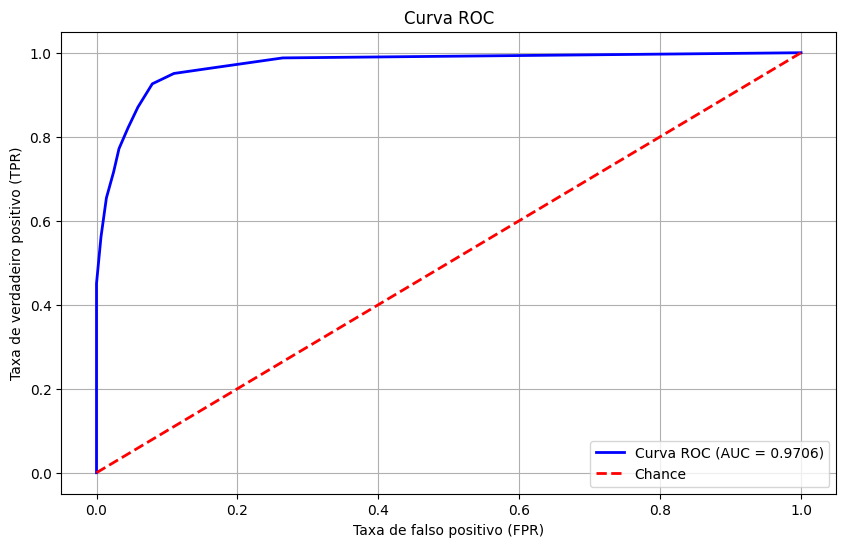

AUC do modelo KNN: 0.9706


In [ ]:
# Plotando a curva ROC
plt.figure(figsize=(10,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Curva ROC (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Chance')
plt.xlabel('Taxa de falso positivo (FPR)')
plt.ylabel('Taxa de verdadeiro positivo (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f'AUC do modelo KNN: {auc:.4f}')

# Curva Precision-Recall

In [ ]:
# Calculando a curva Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_proba)

# Calculando a área sob a curva Precision-Recall (AUCPR)
aucpr = average_precision_score(y_test, y_proba)

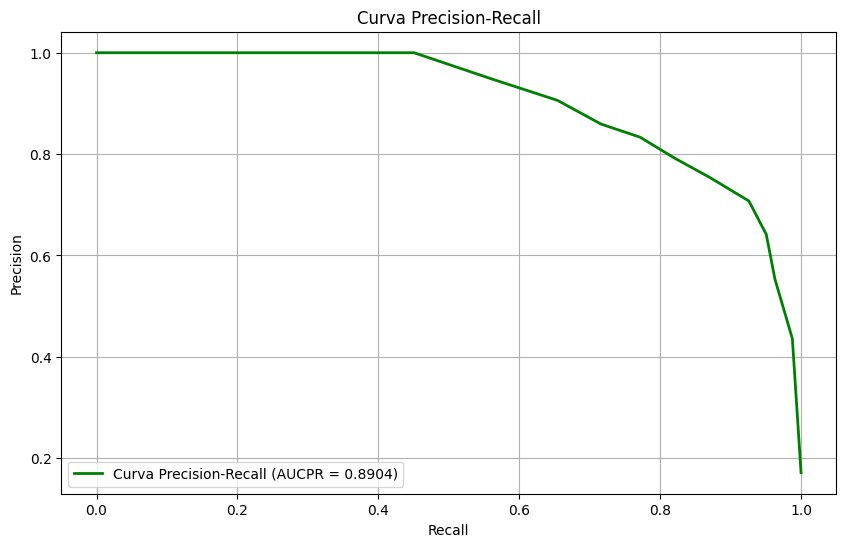

AUCPR do modelo KNN: 0.8904


In [ ]:
# Plotando a curva
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, color='green', lw=2, label=f'Curva Precision-Recall (AUCPR = {aucpr:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

print(f'AUCPR do modelo KNN: {aucpr:.4f}')

# Matriz de confusão e métricas Acurácia, Precision e Recall

In [ ]:
# Calculando a matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred)
print('Matriz de confusão:', conf_matrix)

Matriz de confusão: [[764  19]
 [ 46 116]]


In [ ]:
# Calculando as métricas de avaliação
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Acurácia: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Acurácia: 0.9312
Precision: 0.8593
Recall: 0.7160


# Vantagens e desvantagens do modelo KNN

A adequação do KNN depende de vários fatores, como a natureza dos dados, tamanho da base de dados, dimensionalidade e objetivo da tarefa de modelagem. Considerando que:

- Os dados são de natureza não-linear, ou seja, a idade do cliente, tempo de uso do serviço, tipo de plano contratado e histórico de pagamentos podem influenciar a probabilidade de churn de maneira não linear;

- O tamanho da base de dados não é consideravelmente grande;

- Não há grande dimensionalidade dos dados, pois as características apresentadas não necessariamente influenciam de forma direta e linear o churn;

Sendo assim, o emprego do KNN é potencialmente apropriado para a modelagem preditiva de churn. No entanto, é importante observar se outros modelos de aprendizado de máquina também podem ser considerados, comparando-os para determinar o melhor desempenho preditivo.